# 02 Time of Flight

Run a readout trace as the first readout-characterization experiment after mixer calibration. This notebook estimates the signal arrival sample from the raw ADC envelope and gives you a visual timing check before moving on to resonator scans.

## 1. Shared Session Bootstrap

This notebook expects notebook 00 to have already created the shared session bootstrap. It reopens that same session metadata and uses the active readout frequency from the current runtime attributes.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.compat.notebook import (
    ReadoutTrace,
    close_shared_session,
    get_notebook_session_bootstrap_path,
    get_shared_session,
    require_shared_session,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"
SESSION_BOOTSTRAP_PATH = get_notebook_session_bootstrap_path(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
)

existing_session = get_shared_session()
if existing_session is not None:
    close_shared_session()
session = require_shared_session(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
)
context_snapshot = getattr(session, "context_snapshot", None)
attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
if attr is None:
    raise RuntimeError("Unable to resolve the cQED attribute snapshot from the shared session.")

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Reopened existing in-memory session: {existing_session is not None}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")

2026-03-22 00:49:12,015 - qm - INFO     - Starting session: 36b0f2ed-9147-4bc5-8390-59231082fb8a
[INFO] 2026-03-22 00:49:13,507 qubox.legacy.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:49:13,507 qubox.legacy.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 00:49:13,508 qubox.legacy.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
[INFO] 2026-03-22 00:49:13,509 qubox.legacy.hardware.config_engine: Hardware loaded from E:\qubox\samples\post_cavity_sample_A\config\hardware.json
2026-03-22 00:49:17,358 - qm - INFO     - Performing health check
2026-03-22 00:49:17,362 - qm - INFO     - Health check passed
[INFO] 2026-03-22 00:49:17,374 qubox.legacy.pulses.manager: Loaded pulse files from: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
[I

## 2. Experiment Settings

Edit the reduced-cost verification settings in the next cell. This notebook is intended to run directly top-to-bottom during device bring-up, so the defaults keep the readout trace short while preserving the timing check.

In [4]:
TIME_OF_FLIGHT_DRIVE_FREQUENCY = float(getattr(attr, "ro_fq", 0.0))
TIME_OF_FLIGHT_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)
TIME_OF_FLIGHT_N_AVG = 1000
TIME_OF_FLIGHT_THRESHOLD_FRACTION = 0.20

print("Time-of-flight verification settings:")
print(f"  drive frequency: {TIME_OF_FLIGHT_DRIVE_FREQUENCY / 1e9:.6f} GHz")
print(f"  ro_therm_clks: {TIME_OF_FLIGHT_RO_THERM_CLKS}")
print(f"  n_avg: {TIME_OF_FLIGHT_N_AVG}")
print(f"  threshold fraction: {TIME_OF_FLIGHT_THRESHOLD_FRACTION:.2f}")

Time-of-flight verification settings:
  drive frequency: 8.596223 GHz
  ro_therm_clks: 1000
  n_avg: 1000
  threshold fraction: 0.20


## 3. Run Readout Trace and Estimate Arrival Sample

This cell runs `ReadoutTrace`, plots the raw ADC traces through the experiment's built-in plotting path, then computes an arrival-sample estimate from the envelope crossing of the ADC data. If the QM connection was invalidated by an earlier mixer-calibration restart, the cell reopens the shared session once and retries automatically.

[INFO] 2026-03-22 00:49:23,389 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:49:23,391 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:49:23,392 qubox.legacy.analysis.cQED_attributes: Element bindings: readout='resonator' @ 8.7500 GHz, qubit='transmon' @ 6.1500 GHz, storage='storage' @ 5.3500 GHz
[INFO] 2026-03-22 00:49:23,393 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:49:23,395 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-03-22 00:49:23,396 qubox.legacy.calibration.store: Calibration saved to E:\qubox\samples\post_ca

Running Program...: 100%|█████████▉| 999/1000 [00:00<00:00, 4014.23it/s]

[INFO] 2026-03-22 00:49:24,092 qubox.legacy.hardware.program_runner: Execution report:
Execution report for job 1774142405503
No errors


[INFO] 2026-03-22 00:49:24,143 qubox.legacy.hardware.program_runner: Job halted successfully.


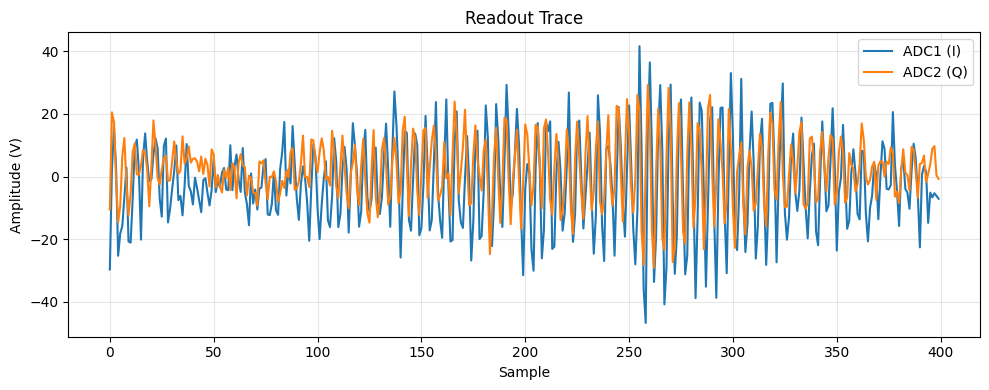

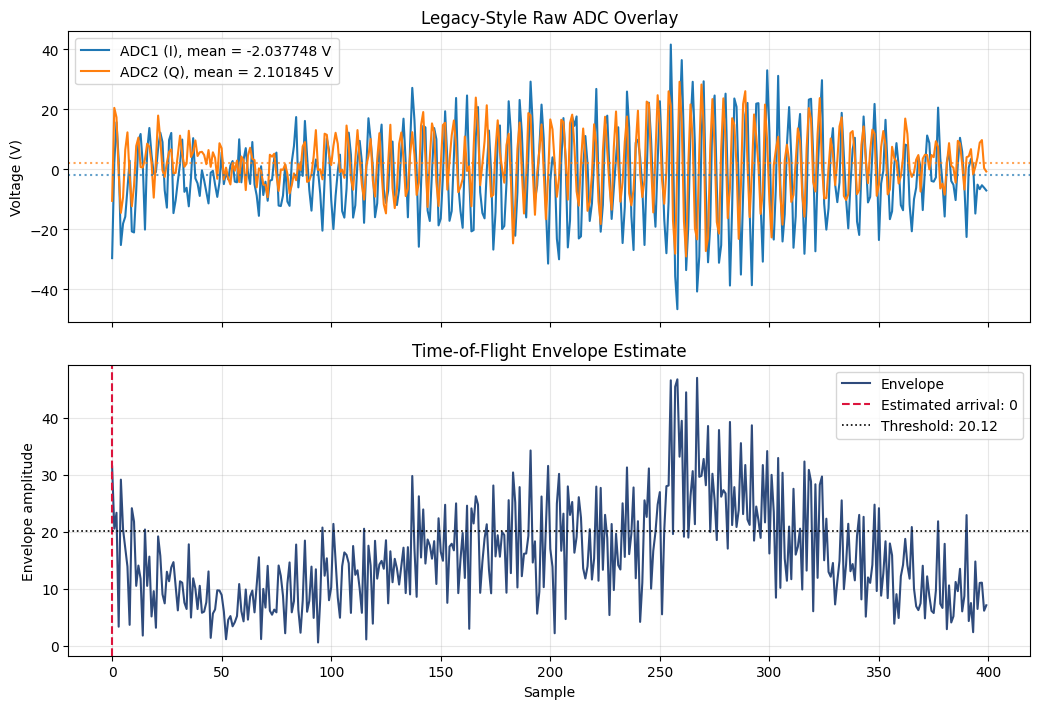

Trace length: 400 samples
ADC1 mean: -2.037748 V
ADC2 mean: 2.101845 V
Estimated arrival sample: 0
Drive vs legacy readout frequency delta: +0.000 MHz


In [ ]:
def estimate_time_of_flight_sample(adc1: np.ndarray, adc2: np.ndarray, threshold_fraction: float = 0.2) -> tuple[int, np.ndarray, float]:
    envelope = np.sqrt(np.square(adc1) + np.square(adc2))
    head = envelope[: min(32, envelope.size)]
    baseline = float(np.median(head)) if head.size else 0.0
    peak = float(np.max(envelope)) if envelope.size else baseline
    threshold = baseline + threshold_fraction * (peak - baseline)
    above = np.flatnonzero(envelope >= threshold)
    sample_index = int(above[0]) if above.size else int(np.argmax(envelope))
    return sample_index, envelope, threshold


def reopen_time_of_flight_session() -> None:
    global session, attr
    close_shared_session()
    session = require_shared_session(
        registry_base=REGISTRY_BASE,
        sample_id=SAMPLE_ID,
        cooldown_id=COOLDOWN_ID,
        qop_ip=QOP_IP,
        cluster_name=CLUSTER_NAME,
        force_reopen=True,
    )
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Unable to resolve the cQED attribute snapshot after reopening the shared session.")


last_error = None
tof_result = None
for attempt in range(2):
    try:
        trace = ReadoutTrace(session)
        tof_result = trace.run(
            drive_frequency=TIME_OF_FLIGHT_DRIVE_FREQUENCY,
            ro_therm_clks=TIME_OF_FLIGHT_RO_THERM_CLKS,
            n_avg=TIME_OF_FLIGHT_N_AVG,
        )
        break
    except Exception as exc:
        last_error = exc
        message = str(exc).lower()
        retryable = "connection lost" in message or "machine not found" in message
        if attempt == 0 and retryable:
            print("ReadoutTrace lost the QM connection; reopening the shared session and retrying once.")
            reopen_time_of_flight_session()
            continue
        raise

if tof_result is None:
    raise RuntimeError(f"ReadoutTrace did not return a result. Last error: {last_error}")

tof_analysis = trace.analyze(tof_result)
trace.plot(tof_analysis)

adc1 = tof_analysis.data.get("adc1")
adc2 = tof_analysis.data.get("adc2")
if adc1 is None or adc2 is None:
    raise RuntimeError("ReadoutTrace output did not contain adc1/adc2 arrays.")

adc1 = np.asarray(adc1, dtype=float)
adc2 = np.asarray(adc2, dtype=float)
sample_axis = np.arange(adc1.size, dtype=float)
adc1_mean = float(np.mean(adc1))
adc2_mean = float(np.mean(adc2))
tof_sample, tof_envelope, tof_threshold = estimate_time_of_flight_sample(
    adc1,
    adc2,
    threshold_fraction=TIME_OF_FLIGHT_THRESHOLD_FRACTION,
)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True)

axes[0].plot(sample_axis, adc1, label=f"ADC1 (I), mean = {adc1_mean:.6f} V")
axes[0].plot(sample_axis, adc2, label=f"ADC2 (Q), mean = {adc2_mean:.6f} V")
axes[0].axhline(adc1_mean, color="#1f77b4", ls=":", alpha=0.7)
axes[0].axhline(adc2_mean, color="#ff7f0e", ls=":", alpha=0.7)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Raw ADC Overlay")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(sample_axis, tof_envelope, label="Envelope", color="#2f4b7c")
axes[1].axvline(tof_sample, color="crimson", ls="--", lw=1.5, label=f"Estimated arrival: {tof_sample}")
axes[1].axhline(tof_threshold, color="black", ls=":", lw=1.2, label=f"Threshold: {tof_threshold:.4g}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Envelope amplitude")
axes[1].set_title("Time-of-Flight Envelope Estimate")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Trace length: {tof_analysis.metrics.get('trace_length', 'N/A')} samples")
print(f"ADC1 mean: {adc1_mean:.6f} V")
print(f"ADC2 mean: {adc2_mean:.6f} V")
print(f"Estimated arrival sample: {tof_sample}")